In [10]:
import numpy as np
import pandas as pd
from src.model.regression_dataset import load_regression_split_dataframes

subset = "mvp"  # change to "processed" for processed runs
dfs = load_regression_split_dataframes(subset=subset)
train_df, val_df = dfs["train"], dfs["val"]

y_val = val_df["fit"].to_numpy(dtype=np.float64)
print("Val rows:", len(val_df), "  Val fit std:", float(y_val.std()))

train_mean_per_gene = train_df.groupby("gene_key")["fit"].mean()
mu_global = float(train_df["fit"].mean())
pred_null = val_df["gene_key"].map(train_mean_per_gene).fillna(mu_global)
rmse_gene_mean_null = float(np.sqrt(np.mean((y_val - pred_null.to_numpy()) ** 2)))
print("RMSE null (train gene mean → val):", rmse_gene_mean_null)

rmse_global = float(np.sqrt(np.mean((y_val - mu_global) ** 2)))
print("RMSE null (global train mean → val):", rmse_global)

Val rows: 869537   Val fit std: 0.7990630415269895
RMSE null (train gene mean → val): 0.799716666185748
RMSE null (global train mean → val): 0.799716666185748


In [1]:
import plot_curves


In [2]:
results = plot_curves.load_all_curves()

In [3]:
results

{'exp21_pairwise_control_mvp': {'experiment': 'exp21_pairwise_control_mvp',
  'config': {'data_subset': 'mvp',
   'epochs_max': '12',
   'batch_size': '2048',
   'early_stop_patience': '3',
   'early_stop_min_delta': '1e-4'},
  'epoch_metrics': [{'epoch': 1,
    'train_mse': 0.32936209043757975,
    'train_rank': 0.10677823822371807,
    'val_rmse': 0.7285874234025108,
    'val_spearman': 0.03543885436990047,
    'lr': 0.0005},
   {'epoch': 2,
    'train_mse': 0.2811428828401594,
    'train_rank': 0.1085206599357595,
    'val_rmse': 0.7204561245838391,
    'val_spearman': 0.03838086212363452,
    'lr': 0.0005},
   {'epoch': 3,
    'train_mse': 0.2686215585790942,
    'train_rank': 0.10902016026556759,
    'val_rmse': 0.7183918146032374,
    'val_spearman': 0.04750594507010957,
    'lr': 0.0005},
   {'epoch': 4,
    'train_mse': 0.2609993888613711,
    'train_rank': 0.10830395477190502,
    'val_rmse': 0.7261831411722054,
    'val_spearman': 0.04825750004588833,
    'lr': 0.0005},
   {'

In [4]:
plot_curves.print_summary_table(results)


Experiment                  Val RMSE   Spearman   Epochs     Subset
--------------------------------------------------------------------------------
exp21_pairwise_control_mvp   0.723505   0.058664       12        mvp
exp22_pairwise_genepacked_mvp   0.726906   0.050138       12        mvp
exp23_pairwise_gp_norm_mvp   0.725836   0.053539       12        mvp
exp24_listwise_genepacked_mvp   0.733424   0.051040       12        mvp
exp25_residual_listwise_mvp   0.764565   0.169419       12        mvp
exp26_residual_pairwise_mvp   0.763268   0.008926       12        mvp
exp27_residual_dual_rank_mvp   0.726942   0.160228       12        mvp
exp28_residual_tuned_mvp    0.722463   0.109881       12        mvp
exp29_huber_residual_mvp    0.734819   0.108709       12        mvp
exp30_wide_offset_mvp       0.729787   0.189153       12        mvp
exp31_freeze_genehead_mvp   0.715607   0.048589       12        mvp


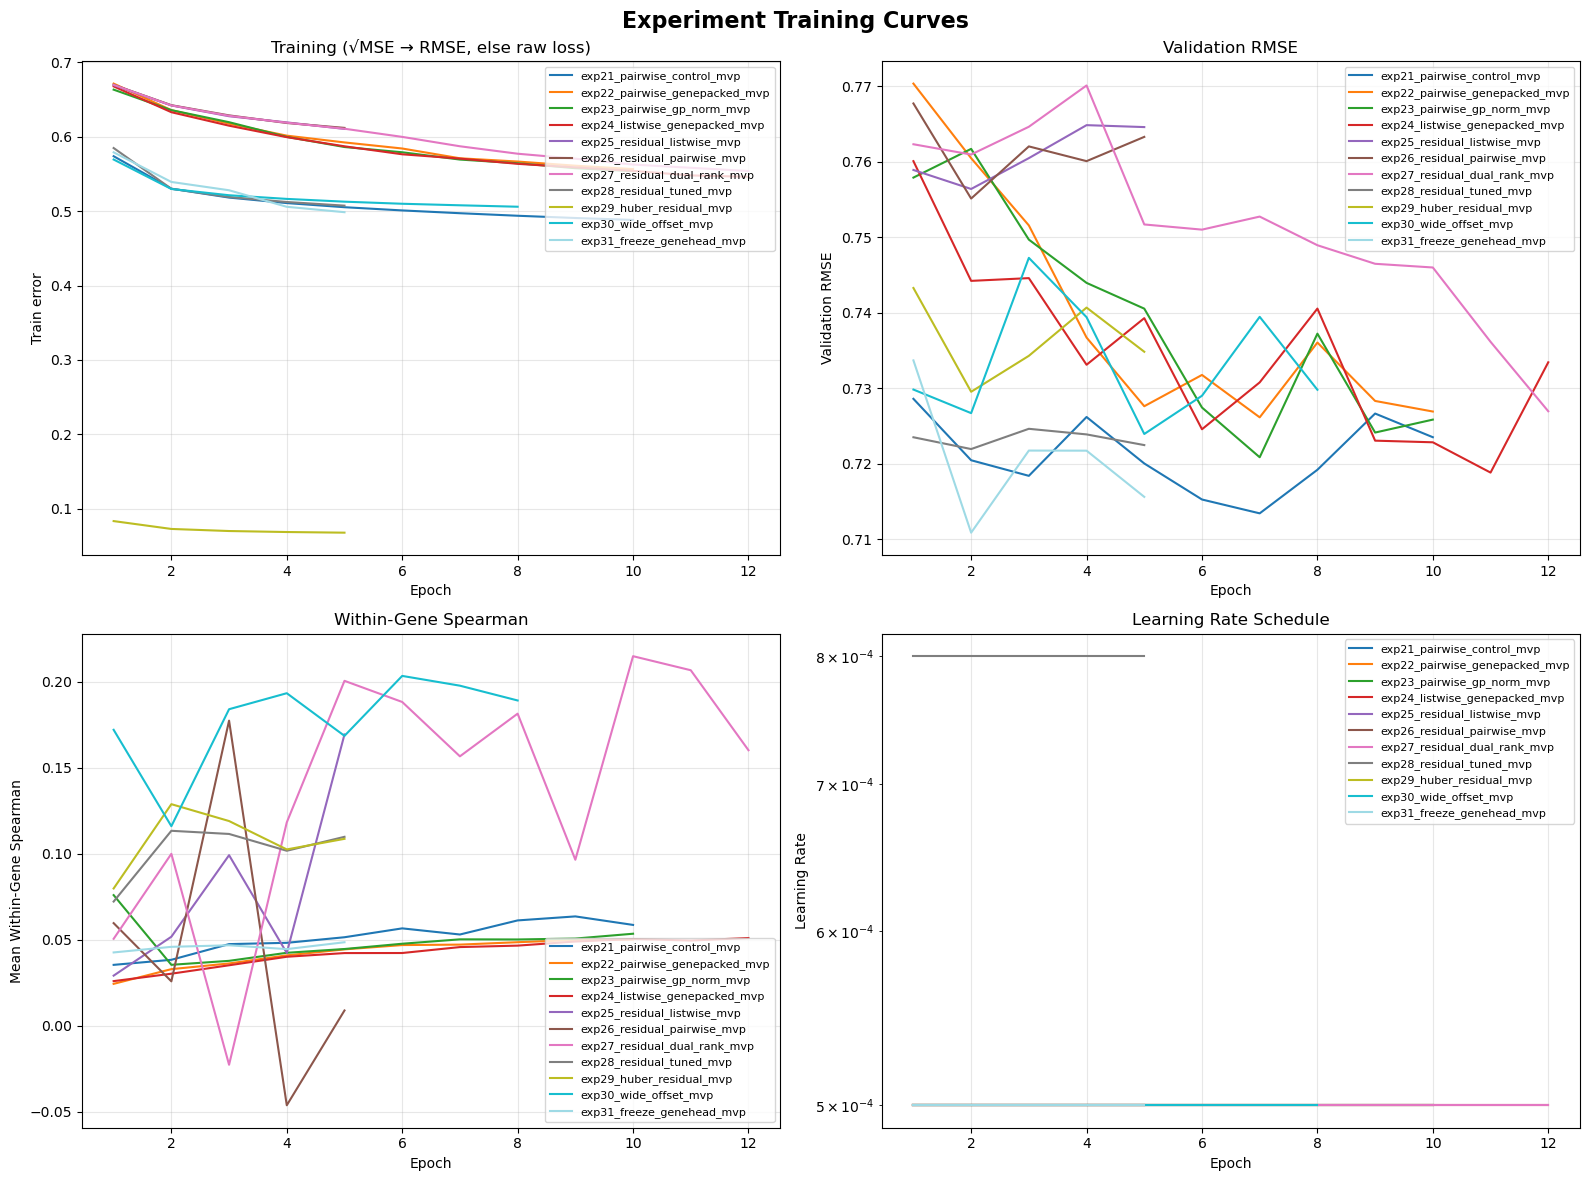

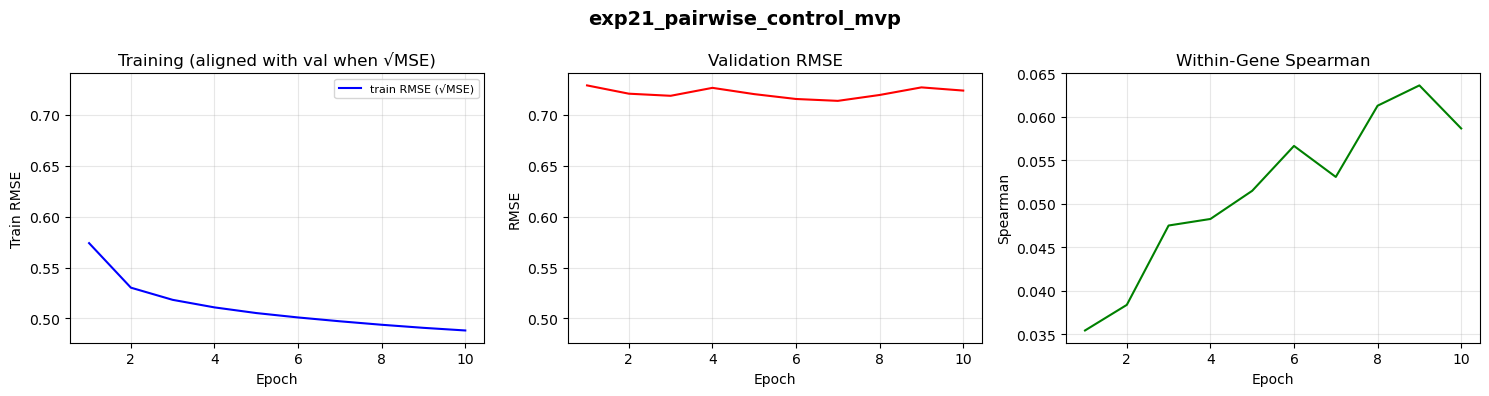

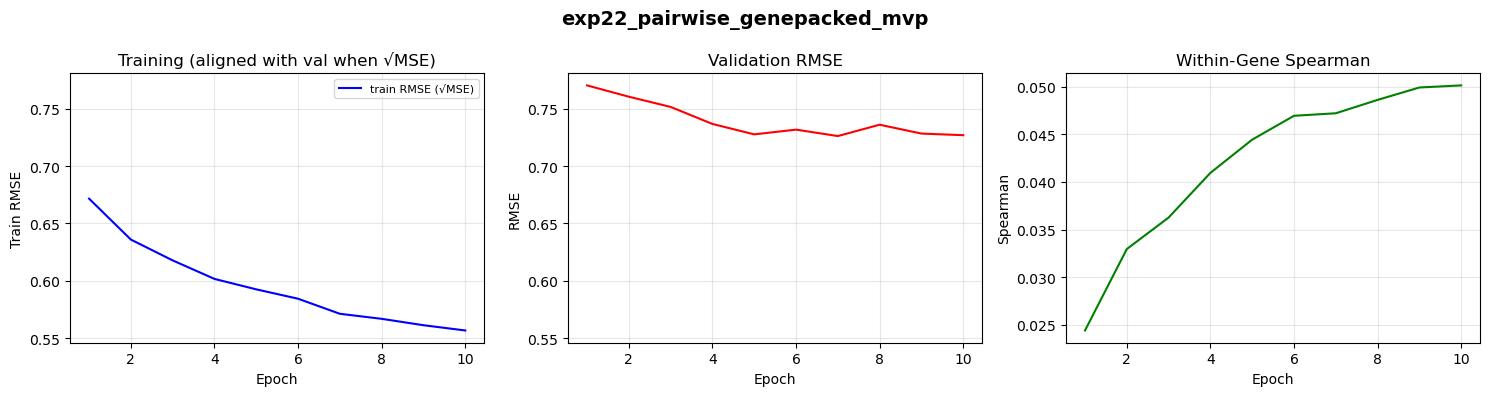

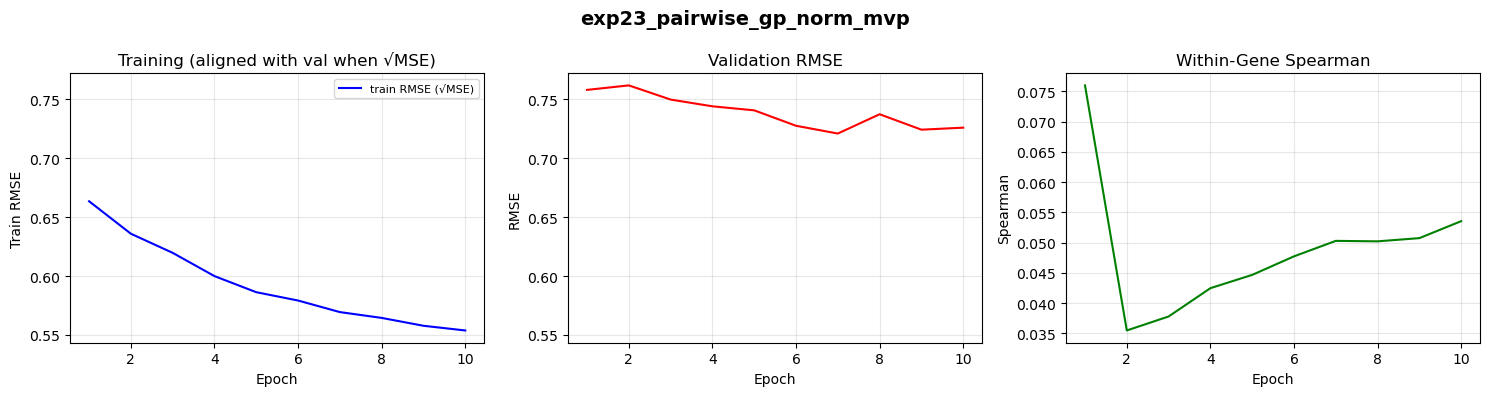

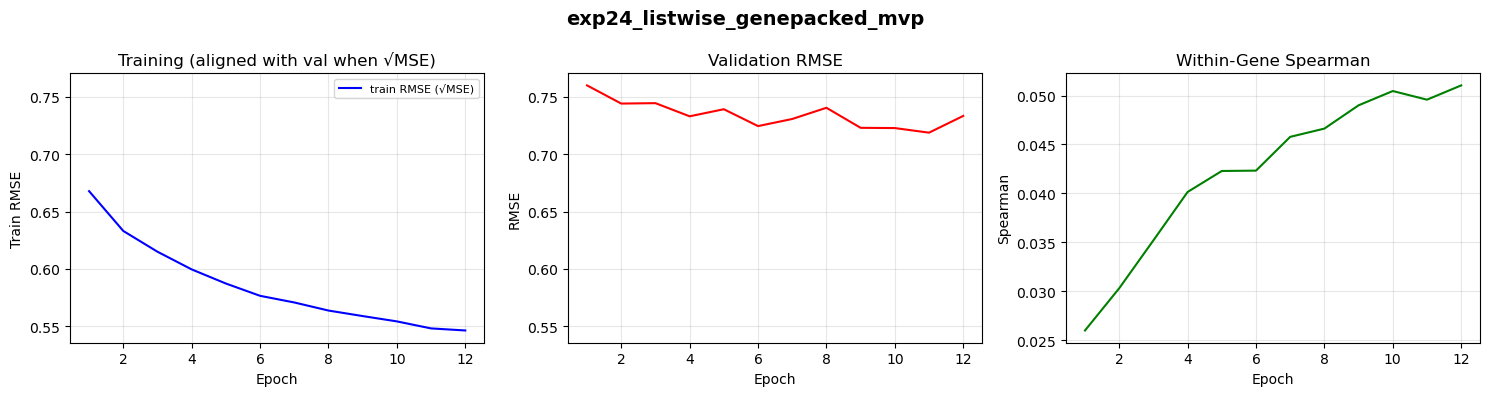

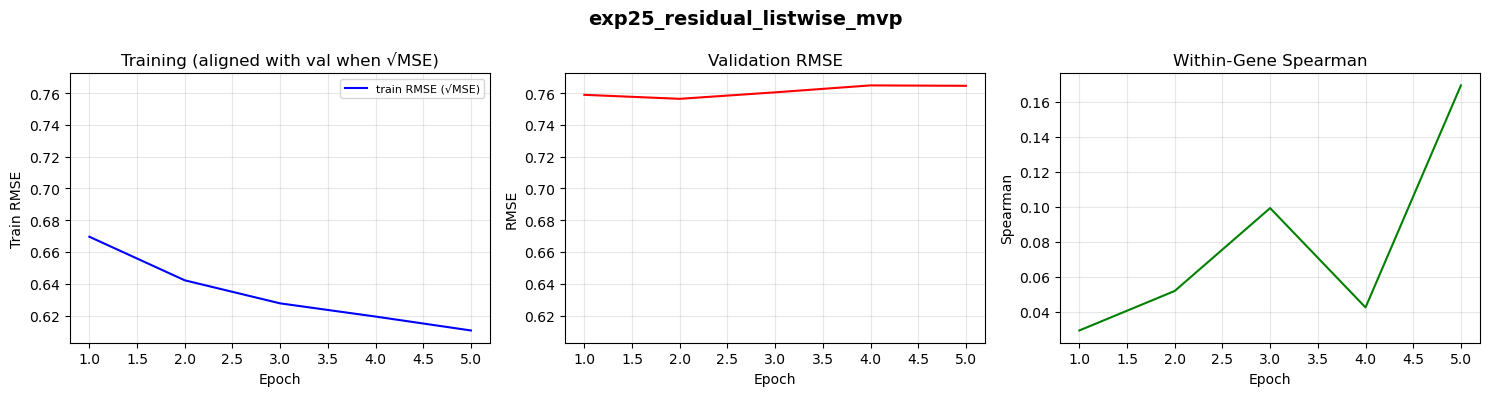

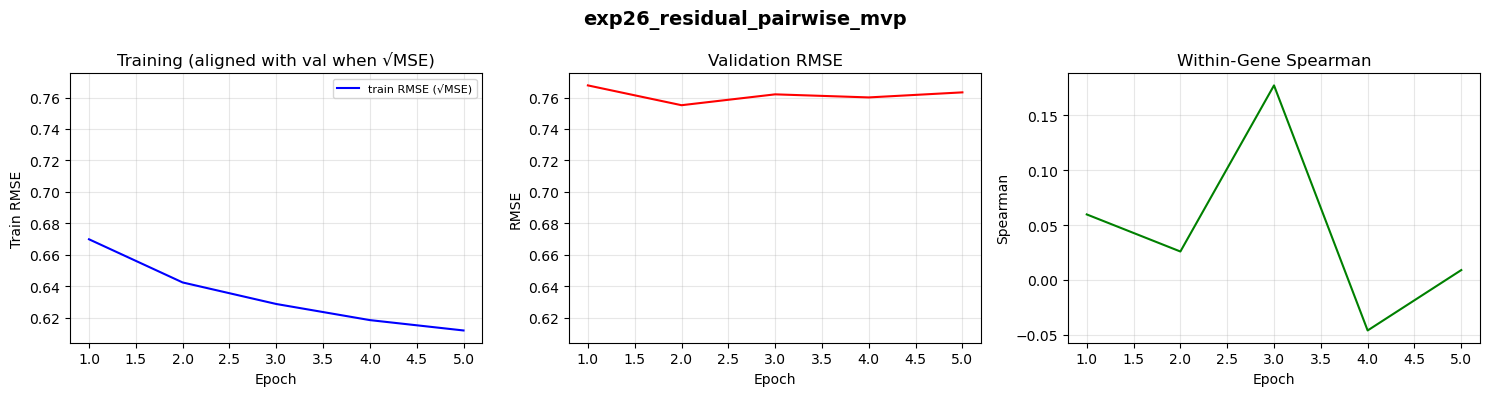

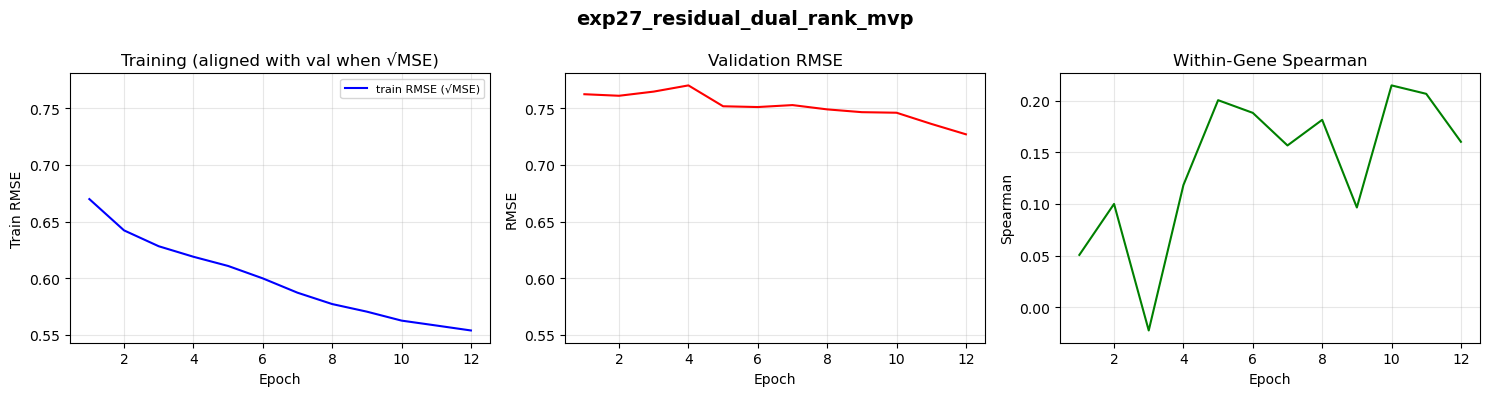

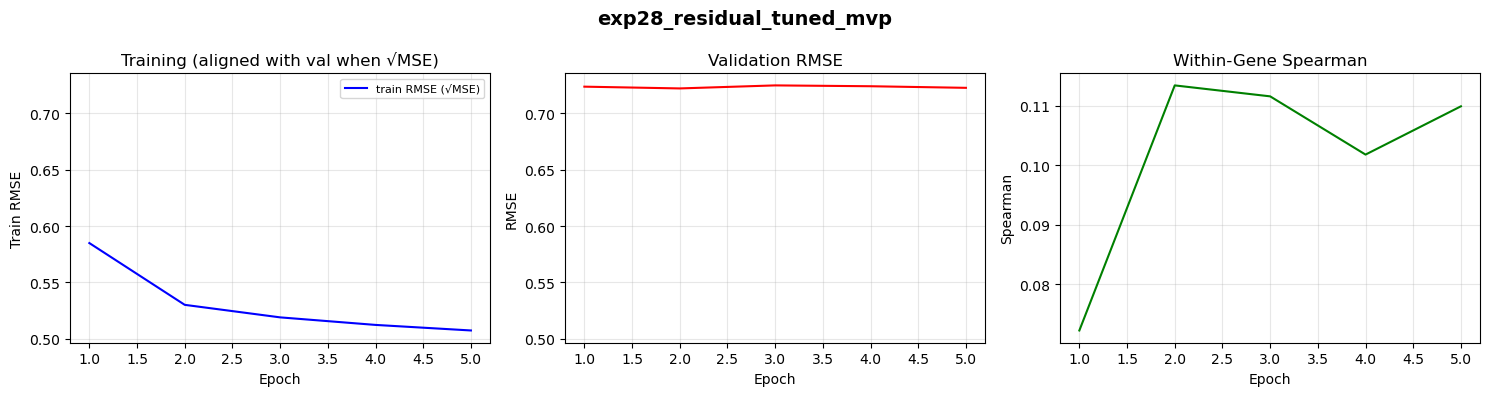

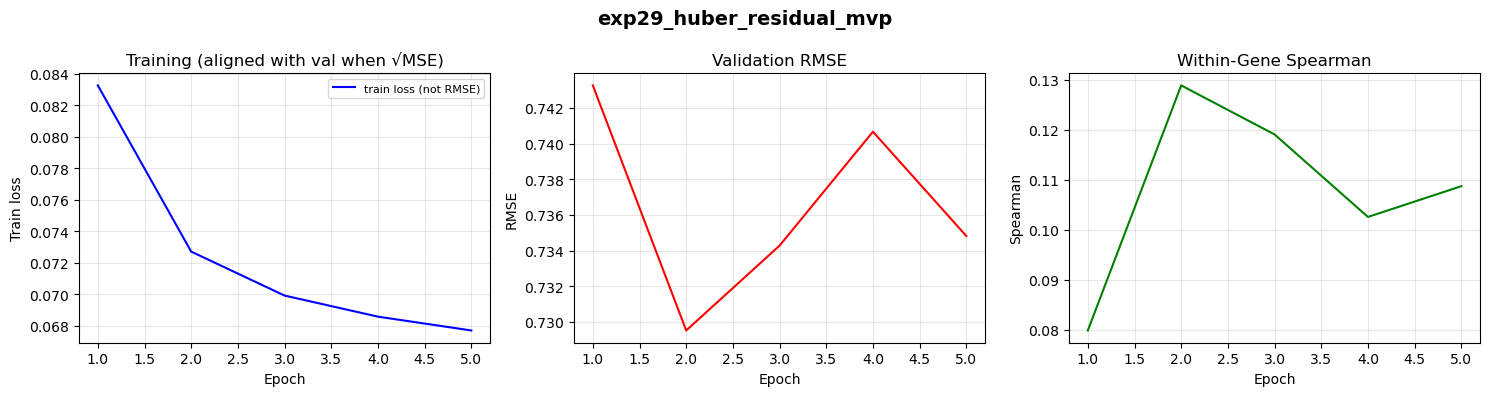

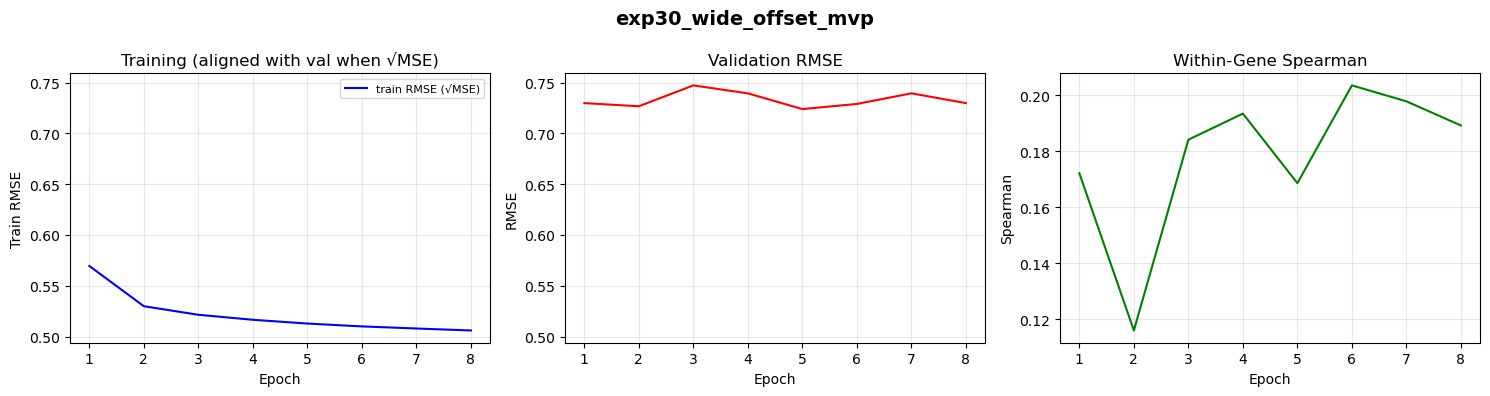

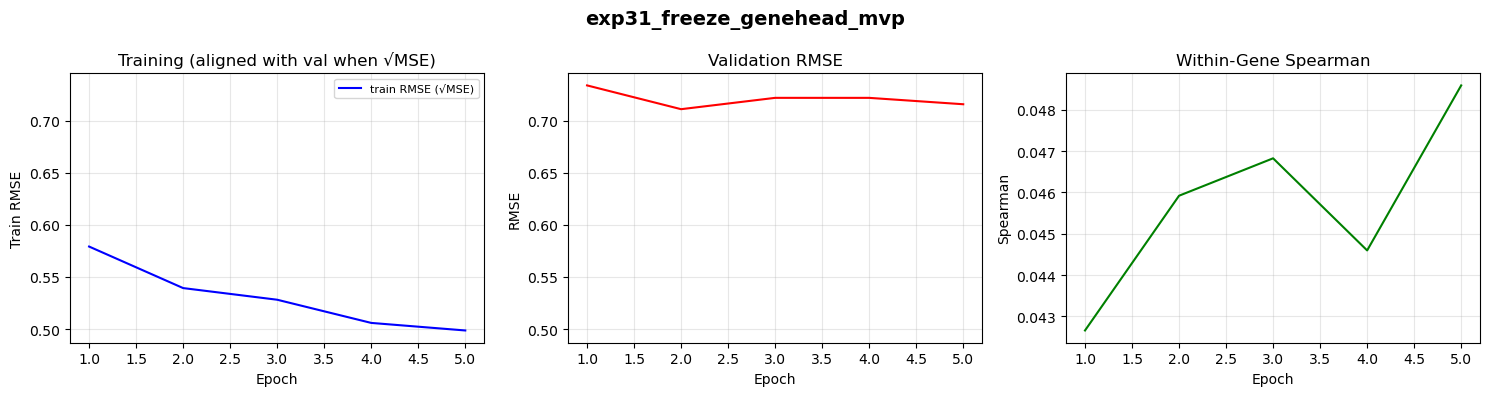

In [5]:
plot_curves.plot_comparison(results)